In [ ]:
# --- الخلية 1: التثبيت وإعادة التشغيل ---
!pip install "numpy<2" matplotlib opencv-python scipy tqdm albumentations segmentation-models-pytorch pandas scikit-learn scikit-image pyarrow fastparquet

import os
import sys

if 'google.colab' in sys.modules:
    print("⏳ جاري تثبيت المكتبات... سيتم إعادة التشغيل.")
    os.kill(os.getpid(), 9)

In [8]:
# --- Cell 2: Global Imports & Device Config ---
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import glob
from tqdm import tqdm
from scipy.signal import resample, find_peaks
import torch
from torch.utils.data import Dataset, DataLoader
import albumentations as A
import segmentation_models_pytorch as smp
from sklearn.model_selection import train_test_split

# إعداد جهاز العمل (GPU/CPU)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"🚀 الجهاز الجاهز للعمل: {DEVICE}")
print(f"✅ تم استيراد كافة المكتبات بنجاح.")

🚀 الجهاز الجاهز للعمل: cuda
✅ تم استيراد كافة المكتبات بنجاح.


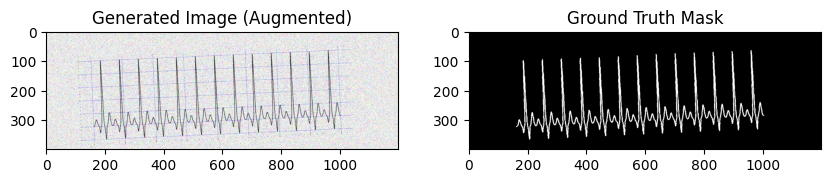

جاري توليد 50 عينة...


100%|██████████| 50/50 [00:10<00:00,  4.89it/s]


In [9]:
# --- الخلية 3: مولد البيانات وتدريب الموديل ---

# 1. إعداد المجلدات
OUTPUT_DIR = "synthetic_dataset"
os.makedirs(f"{OUTPUT_DIR}/images", exist_ok=True)
os.makedirs(f"{OUTPUT_DIR}/masks", exist_ok=True)

class ECGGenerator:
    def __init__(self, sample_rate=500, duration=10):
        self.fs = sample_rate
        self.duration = duration

    def generate_synthetic_heartbeat(self, length):
        t = np.linspace(-1, 1, 100)
        p_wave = 0.1 * np.exp(-((t + 0.7)**2) / 0.02)
        q_wave = -0.1 * np.exp(-((t + 0.3)**2) / 0.005)
        r_wave = 1.0 * np.exp(-(t**2) / 0.005)
        s_wave = -0.2 * np.exp(-((t - 0.3)**2) / 0.005)
        t_wave = 0.2 * np.exp(-((t - 0.7)**2) / 0.02)
        beat = p_wave + q_wave + r_wave + s_wave + t_wave
        
        num_beats = int(length / 150)
        signal = np.tile(beat, num_beats)
        signal = resample(signal, length)
        return signal

    def plot_signal_to_image(self, signal):
        fig_h, fig_w = 4, 12
        dpi = 100
        # الماسك
        fig, ax = plt.subplots(figsize=(fig_w, fig_h), dpi=dpi)
        ax.plot(signal, color='white', linewidth=2.0)
        ax.axis('off'); fig.patch.set_facecolor('black')
        fig.canvas.draw()
        mask_img = np.frombuffer(fig.canvas.tostring_rgb(), dtype=np.uint8)
        mask_img = mask_img.reshape(fig.canvas.get_width_height()[::-1] + (3,))
        mask_img = cv2.cvtColor(mask_img, cv2.COLOR_RGB2GRAY)
        _, mask_img = cv2.threshold(mask_img, 10, 255, cv2.THRESH_BINARY)
        plt.close(fig)

        # الصورة
        fig, ax = plt.subplots(figsize=(fig_w, fig_h), dpi=dpi)
        ax.minorticks_on()
        ax.grid(which='major', linestyle='-', linewidth='0.8', color='red', alpha=0.5)
        ax.grid(which='minor', linestyle=':', linewidth='0.5', color='red', alpha=0.3)
        ax.plot(signal, color='black', linewidth=1.2)
        ax.set_xticklabels([]); ax.set_yticklabels([])
        for spine in ax.spines.values(): spine.set_visible(False)
        fig.canvas.draw()
        input_img = np.frombuffer(fig.canvas.tostring_rgb(), dtype=np.uint8)
        input_img = input_img.reshape(fig.canvas.get_width_height()[::-1] + (3,))
        input_img = cv2.cvtColor(input_img, cv2.COLOR_RGB2BGR)
        plt.close(fig)
        return input_img, mask_img

    def augment_pair(self, image, mask):
        aug = A.Compose([
            A.Affine(rotate=(-5, 5), scale=(0.95, 1.05), translate_percent=(-0.05, 0.05),
                     interpolation=cv2.INTER_LINEAR, mask_interpolation=cv2.INTER_NEAREST,
                     border_mode=cv2.BORDER_CONSTANT, fill=[255, 255, 255], fill_mask=0, p=0.8),
            A.GaussNoise(p=0.5), A.Blur(blur_limit=3, p=0.3),
            A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.4),
        ])
        if image.dtype != np.uint8: image = image.astype(np.uint8)
        if mask.dtype != np.uint8: mask = mask.astype(np.uint8)
        out = aug(image=image, mask=mask)
        return out["image"], out["mask"]

# --- التنفيذ والعرض ---
generator = ECGGenerator()
# توليد عينة واحدة للعرض المباشر (للتأكد)
sig = generator.generate_synthetic_heartbeat(length=2000)
img, mask = generator.plot_signal_to_image(sig)
aug_img, aug_mask = generator.augment_pair(img, mask)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1); plt.title("Generated Image (Augmented)"); plt.imshow(aug_img)
plt.subplot(1, 2, 2); plt.title("Ground Truth Mask"); plt.imshow(aug_mask, cmap='gray')
plt.show()

# توليد مجموعة البيانات
print("جاري توليد 50 عينة...")
for i in tqdm(range(50)):
    sig = generator.generate_synthetic_heartbeat(length=2000)
    img, mask = generator.plot_signal_to_image(sig)
    aug_img, aug_mask = generator.augment_pair(img, mask)
    cv2.imwrite(f"{OUTPUT_DIR}/images/sample_{i}.png", aug_img)
    cv2.imwrite(f"{OUTPUT_DIR}/masks/sample_{i}.png", aug_mask)

🚀 بدء التدريب...
Epoch 1 | Loss: 0.7765
Epoch 2 | Loss: 0.6709
Epoch 3 | Loss: 0.5949
Epoch 4 | Loss: 0.5104
Epoch 5 | Loss: 0.4189
Epoch 6 | Loss: 0.3252
Epoch 7 | Loss: 0.2497
Epoch 8 | Loss: 0.1974
Epoch 9 | Loss: 0.1626
Epoch 10 | Loss: 0.1400


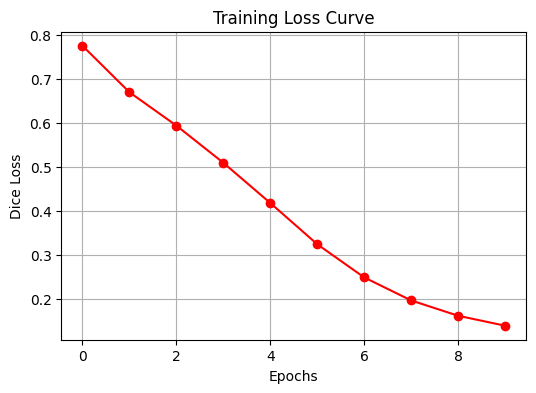

In [10]:
# --- الخلية 4: التدريب ورسم النتائج ---

class ECGDataset(Dataset):
    def __init__(self, data_dir):
        self.data_dir = data_dir
        self.images = sorted(os.listdir(os.path.join(data_dir, "images")))
        self.masks = sorted(os.listdir(os.path.join(data_dir, "masks")))
    def __len__(self): return len(self.images)
    def __getitem__(self, idx):
        img_path = os.path.join(self.data_dir, "images", self.images[idx])
        mask_path = os.path.join(self.data_dir, "masks", self.masks[idx])
        image = cv2.imread(img_path); image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        image = cv2.resize(image, (512, 256)); mask = cv2.resize(mask, (512, 256), interpolation=cv2.INTER_NEAREST)
        image = image.transpose(2, 0, 1).astype('float32') / 255.0
        mask = np.expand_dims(np.round(mask.astype('float32') / 255.0), axis=0)
        return torch.from_numpy(image), torch.from_numpy(mask)

dataset = ECGDataset(OUTPUT_DIR)
dataloader = DataLoader(dataset, batch_size=8, shuffle=True)

model = smp.Unet(encoder_name="resnet18", encoder_weights="imagenet", in_channels=3, classes=1).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)
loss_fn = smp.losses.DiceLoss(mode='binary')

history = []
print("🚀 بدء التدريب...")
for epoch in range(10):
    model.train()
    epoch_loss = 0
    for images, masks in dataloader:
        images, masks = images.to(DEVICE), masks.to(DEVICE)
        optimizer.zero_grad()
        prediction = model(images)
        loss = loss_fn(prediction, masks)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    avg_loss = epoch_loss/len(dataloader)
    history.append(avg_loss)
    print(f"Epoch {epoch+1} | Loss: {avg_loss:.4f}")

# --- رسم منحنى التعلم ---
plt.figure(figsize=(6, 4))
plt.plot(history, marker='o', color='red')
plt.title("Training Loss Curve")
plt.xlabel("Epochs"); plt.ylabel("Dice Loss")
plt.grid(True)
plt.show()

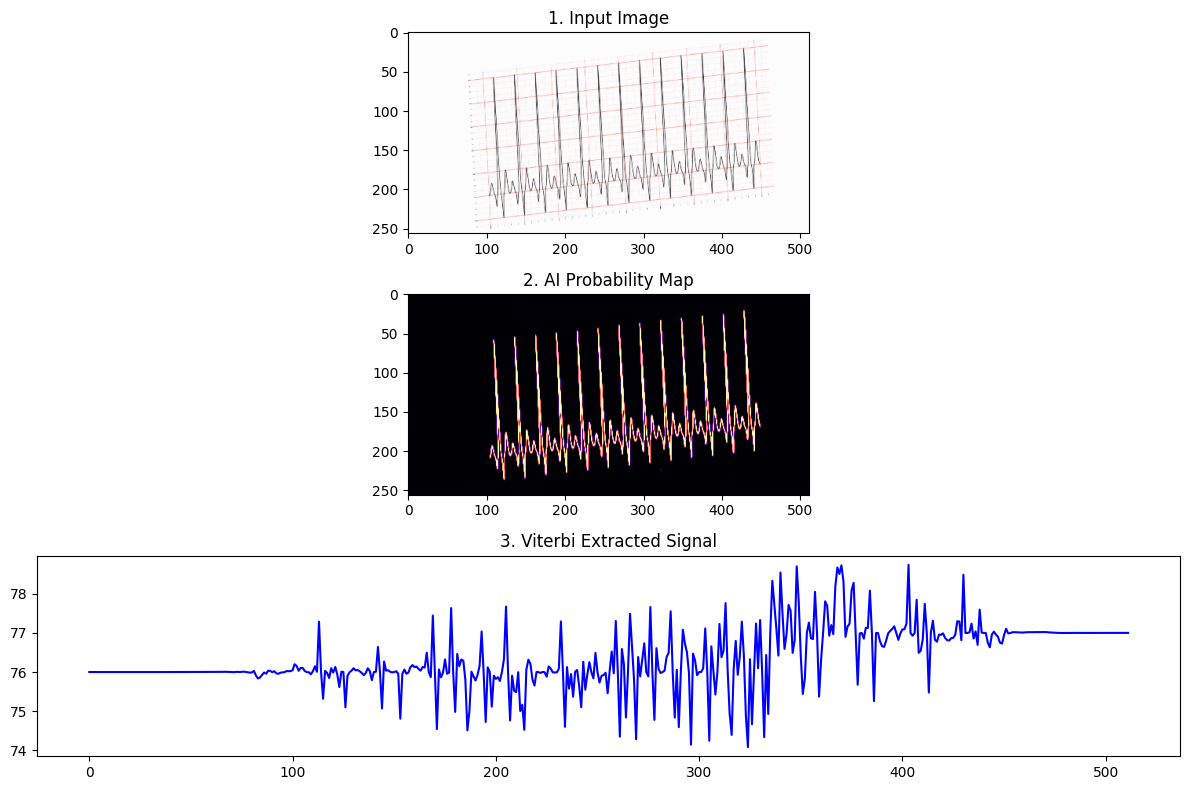

In [11]:
# --- الخلية 5: خوارزميات المعالجة واختبارها بصرياً ---

# 1. دالة Viterbi (استخراج المسار)
def viterbi_extract_actual_signal(prob_map, lam=10.0, max_jump=10):
    H, W = prob_map.shape
    cost_map = -np.log(prob_map + 1e-6)
    dp = np.full((H, W), np.inf); parent = np.zeros((H, W), dtype=int)
    dp[:, 0] = cost_map[:, 0]
    
    for x in range(1, W):
        for y in range(H):
            y_min = max(0, y - max_jump); y_max = min(H, y + max_jump + 1)
            prev_costs = dp[y_min:y_max, x-1]
            dist_penalty = lam * np.abs(np.arange(y_min, y_max) - y)
            total = prev_costs + dist_penalty
            best_idx = np.argmin(total)
            dp[y, x] = cost_map[y, x] + total[best_idx]
            parent[y, x] = y_min + best_idx
            
    path = np.zeros(W, dtype=int)
    path[-1] = np.argmin(dp[:, -1])
    for x in range(W-2, -1, -1): path[x] = parent[path[x+1], x+1]
    
    final_signal = []
    for x, y_int in enumerate(path):
        y_start = max(0, y_int - 2); y_end = min(H, y_int + 3)
        w_slice = prob_map[y_start:y_end, x]
        if np.sum(w_slice) > 1e-5: y_sub = np.sum(w_slice * np.arange(y_start, y_end)) / np.sum(w_slice)
        else: y_sub = y_int
        final_signal.append(H - y_sub)
    return np.array(final_signal)

# 2. إزالة الشبكة
def preprocess_remove_grid(image):
    if image is None: return None
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    lower_red1 = np.array([0, 50, 50]); upper_red1 = np.array([10, 255, 255])
    lower_red2 = np.array([170, 50, 50]); upper_red2 = np.array([180, 255, 255])
    mask = cv2.inRange(hsv, lower_red1, upper_red1) + cv2.inRange(hsv, lower_red2, upper_red2)
    kernel = np.ones((2,2), np.uint8)
    mask = cv2.dilate(mask, kernel, iterations=1)
    image_clean = image.copy()
    image_clean[mask > 0] = (255, 255, 255)
    return image_clean

# --- اختبار بصري (Visual Check) ---
# سنأخذ صورة عشوائية ونرى كيف يراها الموديل وكيف يقرأها فيتيربي
model.eval()
with torch.no_grad():
    test_idx = random.randint(0, len(dataset)-1)
    img_tensor, _ = dataset[test_idx]
    input_batch = img_tensor.unsqueeze(0).to(DEVICE)
    pred_raw = model(input_batch)
    prob_map = torch.sigmoid(pred_raw).cpu().numpy()[0][0]
    
    extracted_sig = viterbi_extract_actual_signal(prob_map)

plt.figure(figsize=(12, 8))
plt.subplot(3, 1, 1); plt.title("1. Input Image"); plt.imshow(img_tensor.permute(1, 2, 0))
plt.subplot(3, 1, 2); plt.title("2. AI Probability Map"); plt.imshow(prob_map, cmap='magma')
plt.subplot(3, 1, 3); plt.title("3. Viterbi Extracted Signal"); plt.plot(extracted_sig, color='blue')
plt.tight_layout(); plt.show()

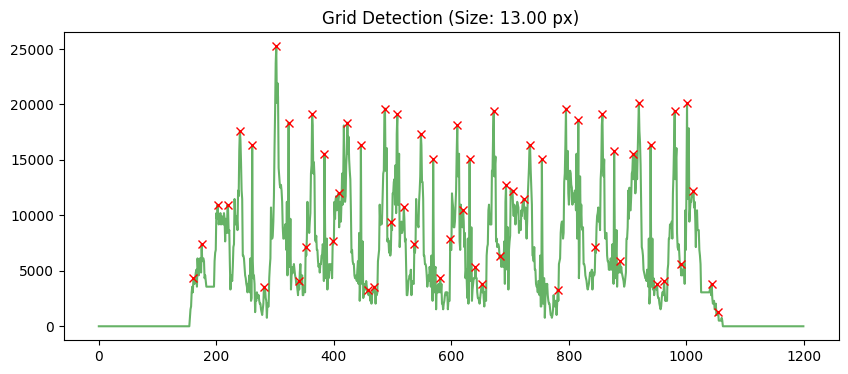

In [12]:
# --- الخلية 6: المعايرة واكتشاف الشبكة (مع الرسم) ---

def estimate_grid_size(image_array, display=True):
    if image_array is None: return 25.0
    gray = cv2.cvtColor(image_array, cv2.COLOR_BGR2GRAY)
    edges = cv2.Canny(gray, 50, 150)
    row_sum = np.sum(edges, axis=1); col_sum = np.sum(edges, axis=0)
    peaks_x, _ = find_peaks(col_sum, distance=10, prominence=50)
    peaks_y, _ = find_peaks(row_sum, distance=10, prominence=50)
    
    val_x = np.median(np.diff(peaks_x)) if len(peaks_x) > 1 else 0
    val_y = np.median(np.diff(peaks_y)) if len(peaks_y) > 1 else 0
    final_size = (val_x + val_y) / 2 if (val_x > 0 and val_y > 0) else max(val_x, val_y)
    final_size = final_size if final_size > 5 else 25.0

    if display:
        plt.figure(figsize=(10, 4))
        plt.plot(col_sum, color='green', alpha=0.6)
        plt.plot(peaks_x, col_sum[peaks_x], "x", color='red')
        plt.title(f"Grid Detection (Size: {final_size:.2f} px)")
        plt.show()
    return final_size

def calibrate_signal(raw_signal, grid_size_pixels):
    pixels_per_mV = grid_size_pixels * 10 
    return (raw_signal - np.median(raw_signal)) / pixels_per_mV

# --- تجربة الرسم ---
# نقوم بتجربة الدالة على آخر صورة تم توليدها
_ = estimate_grid_size(aug_img, display=True)

✅ وجدنا 8795 صورة حقيقية. نعرض عينة:


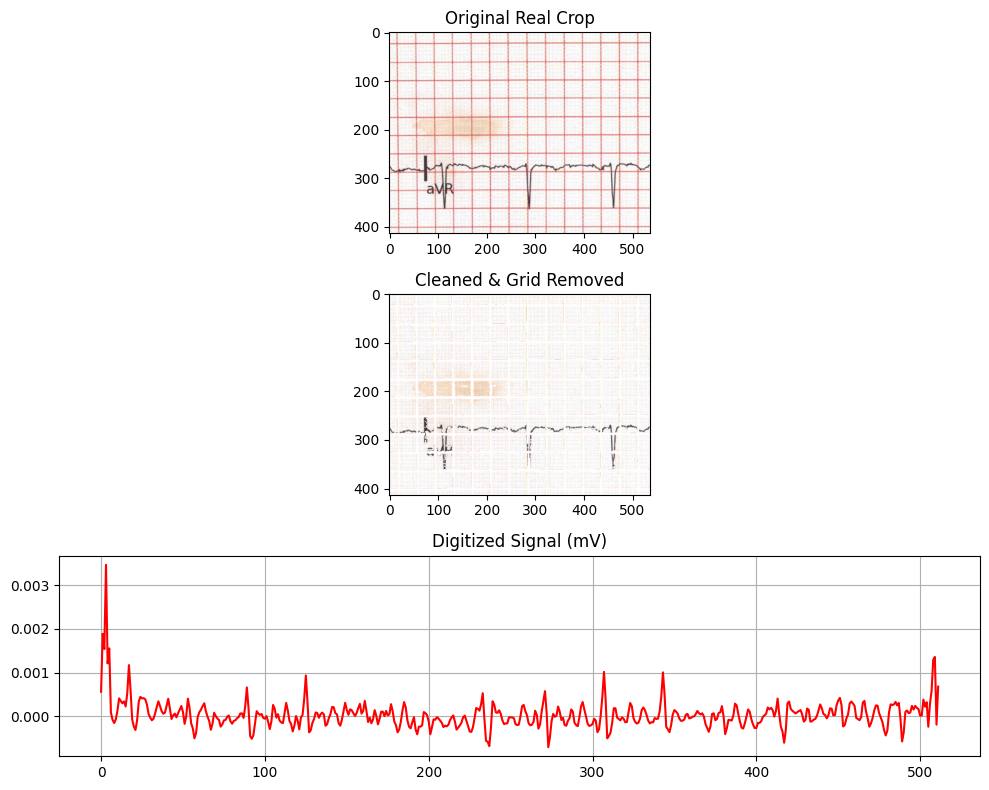

In [14]:
# --- الخلية 7: اختبار على صور واقعية (مع الرسم) ---

def correct_skew_orientation(image):
    if image is None: return None
    gray = cv2.bitwise_not(cv2.cvtColor(image, cv2.COLOR_BGR2GRAY))
    thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)[1]
    coords = np.column_stack(np.where(thresh > 0))
    angle = cv2.minAreaRect(coords)[-1]
    if angle < -45: angle = -(90 + angle)
    else: angle = -angle
    if abs(angle) < 0.5: return image
    (h, w) = image.shape[:2]
    M = cv2.getRotationMatrix2D((w // 2, h // 2), angle, 1.0)
    return cv2.warpAffine(image, M, (w, h), flags=cv2.INTER_CUBIC, borderMode=cv2.BORDER_REPLICATE)

# البحث عن صور حقيقية
INPUT_DIR = "/kaggle/input" 
dataset_path = None
for dirname in os.listdir(INPUT_DIR):
    if "physionet" in dirname or "ecg" in dirname:
        dataset_path = os.path.join(INPUT_DIR, dirname)
        break

if dataset_path:
    real_images = glob.glob(f"{dataset_path}/**/*.png", recursive=True) + glob.glob(f"{dataset_path}/**/*.jpg", recursive=True)
    if real_images:
        print(f"✅ وجدنا {len(real_images)} صورة حقيقية. نعرض عينة:")
        
        # اختيار صورة عشوائية
        test_img_path = random.choice(real_images)
        original_img = cv2.imread(test_img_path)
        
        # 1. تصحيح الميل
        corrected = correct_skew_orientation(original_img)
        # 2. قص جزء (Lead) للتجربة
        h, w = corrected.shape[:2]
        crop = corrected[h//4:h//2, w//4:w//2]
        
        # 3. إزالة الشبكة
        clean_crop = preprocess_remove_grid(crop)
        
        # 4. التوقع
        input_tensor = cv2.resize(clean_crop, (512, 256))
        input_tensor = torch.from_numpy(input_tensor).permute(2, 0, 1).float() / 255.0
        input_tensor = input_tensor.unsqueeze(0).to(DEVICE)
        
        model.eval()
        with torch.no_grad():
            prob = torch.sigmoid(model(input_tensor)).cpu().numpy()[0][0]
        
        raw_sig = viterbi_extract_actual_signal(prob)
        grid_size = estimate_grid_size(crop, display=False)
        calib_sig = calibrate_signal(raw_sig, grid_size * (256/crop.shape[0]))

        # --- الرسم للمقارنة ---
        plt.figure(figsize=(10, 8))
        plt.subplot(3, 1, 1); plt.title("Original Real Crop"); plt.imshow(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))
        plt.subplot(3, 1, 2); plt.title("Cleaned & Grid Removed"); plt.imshow(cv2.cvtColor(clean_crop, cv2.COLOR_BGR2RGB))
        plt.subplot(3, 1, 3); plt.title("Digitized Signal (mV)"); plt.plot(calib_sig, color='red'); plt.grid(True)
        plt.tight_layout(); plt.show()
    else:
        print("⚠️ لم يتم العثور على صور، تأكد من إضافة البيانات.")

In [16]:
# --- الخلية 8: الحفظ النهائي ---
# دوال القص والتحكم
def smart_crop_12_leads(image):
    h, w = image.shape[:2]
    margin_x = int(w * 0.01); margin_y = int(h * 0.01)
    active_img = image[margin_y:h-margin_y, margin_x:w-margin_x]
    ah, aw = active_img.shape[:2]
    row_h = ah // 4; col_w = aw // 3
    crops = []
    for r in range(4):
        for c in range(3):
            crops.append(active_img[r*row_h:(r+1)*row_h, c*col_w:(c+1)*col_w])
    return crops

# تجهيز القائمة
if dataset_path:
    test_csv = os.path.join(dataset_path, "test.csv")
    test_df = pd.read_csv(test_csv) if os.path.exists(test_csv) else pd.DataFrame({'id': ['001'], 'fs': [500]})
    id_to_path = {os.path.splitext(os.path.basename(p))[0]: p for p in real_images}
else:
    test_df = pd.DataFrame() # فارغ

long_ids = []
long_values = []
LEAD_NAMES = ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']

print(f"🚀 بدء المعالجة النهائية لـ {len(test_df)} ملف...")

for idx, row in tqdm(test_df.iterrows(), total=len(test_df)):
    sample_id = str(row['id'])
    fs = row['fs'] if 'fs' in row else 500
    target_len = int(10 * fs)
    img_path = id_to_path.get(sample_id)
    
    current_leads = []
    if img_path:
        try:
            img = cv2.imread(img_path)
            img = correct_skew_orientation(img)
            img = preprocess_remove_grid(img)
            crops = smart_crop_12_leads(img)
            
            for crop in crops:
                # تصغير ومعالجة
                inp = cv2.resize(crop, (512, 256))
                inp_t = torch.from_numpy(inp).permute(2, 0, 1).float()/255.0
                with torch.no_grad():
                    prob = torch.sigmoid(model(inp_t.unsqueeze(0).to(DEVICE))).cpu().numpy()[0][0]
                
                raw = viterbi_extract_actual_signal(prob)
                grid = estimate_grid_size(crop, display=False)
                scale = 256/crop.shape[0]
                calib = calibrate_signal(raw, grid*scale)
                final = resample(calib, target_len)
                current_leads.append(final)
        except:
            current_leads = [np.zeros(target_len)]*12
    else:
        current_leads = [np.zeros(target_len)]*12

    if len(current_leads) < 12: current_leads = [np.zeros(target_len)]*12
    
    for i, sig in enumerate(current_leads[:12]):
        lead_ids = [f"{sample_id}_{k}_{LEAD_NAMES[i]}" for k in range(target_len)]
        long_ids.extend(lead_ids)
        long_values.extend(sig)

# حفظ
sub = pd.DataFrame({'id': long_ids, 'value': long_values})
sub.to_parquet("submission.parquet", index=False)
sub.to_csv("submission.csv", index=False)
print("✅ تم الحفظ بنجاح.")

🚀 بدء المعالجة النهائية لـ 24 ملف...


100%|██████████| 24/24 [05:30<00:00, 13.76s/it]


✅ تم الحفظ بنجاح.
